1)Imports

In [2]:
!pip install transformers datasets scikit-learn

import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader

In [3]:
import torch

# Define device FIRST
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

# Move model to device
model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [4]:
print(torch.cuda.is_available())

True


In [8]:
from google.colab import files
uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset.csv


2)Load dataset

In [9]:
import pandas as pd

df = pd.read_csv("IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


3)Preprocessing

In [10]:
# Convert labels to numeric
df['label'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})

# Basic cleaning
df['review'] = df['review'].str.lower()

# Remove missing values
df = df.dropna()

df.head()

,review,sentiment,label
0,one of the other reviewers has mentioned that ...,positive,1
1,a wonderful little production. <br /><br />the...,positive,1
2,i thought this was a wonderful way to spend ti...,positive,1
3,basically there's a family where a little boy ...,negative,0
4,"petter mattei's ""love in the time of money"" is...",positive,1


4)Train / Validation / Test Split

In [21]:
df = df.sample(5000, random_state=42)

In [22]:
from sklearn.model_selection import train_test_split

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['review'], df['label'], test_size=0.2, random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42
)

5)Tokenization (BERT)

In [23]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(list(train_texts), truncation=True, padding=True)
val_encodings = tokenizer(list(val_texts), truncation=True, padding=True)
test_encodings = tokenizer(list(test_texts), truncation=True, padding=True)

In [24]:
train_encodings = tokenizer(list(train_texts), truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(list(val_texts), truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(list(test_texts), truncation=True, padding=True, max_length=128)

6)Create Dataset Class

In [25]:
from torch.utils.data import Dataset

class IMDbDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [26]:
train_dataset = IMDbDataset(train_encodings, train_labels)
val_dataset = IMDbDataset(val_encodings, val_labels)
test_dataset = IMDbDataset(test_encodings, test_labels)

In [27]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

In [28]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=2e-5)

TRAINING LOOP + EVALUATION +RESULTS

In [52]:
def run_experiment(model, train_loader, test_loader, device, mode="full", epochs=3):

    # Reset model weights (important if reusing)
    from transformers import AutoModelForSequenceClassification
    model = AutoModelForSequenceClassification.from_pretrained(
        "bert-base-uncased",
        num_labels=2
    ).to(device)

    # Apply experiment mode
    if mode == "freeze":
        for param in model.bert.parameters():
            param.requires_grad = False

    elif mode == "last2":
        for name, param in model.bert.named_parameters():
            if "encoder.layer.10" in name or "encoder.layer.11" in name:
                param.requires_grad = True
            else:
                param.requires_grad = False

    # Optimizer (only trainable params)
    from torch.optim import AdamW
    optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5)

    # Training
    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for batch in train_loader:
            optimizer.zero_grad()

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"{mode.upper()} Epoch {epoch+1} Loss: {total_loss/len(train_loader)}")

    # Evaluation
    model.eval()
    preds, true = [], []

    import torch
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            predictions = torch.argmax(logits, dim=1)

            preds.extend(predictions.cpu().numpy())
            true.extend(labels.cpu().numpy())

    # Metrics
    from sklearn.metrics import accuracy_score, precision_recall_fscore_support

    accuracy = accuracy_score(true, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(true, preds, average='binary')

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }, preds, true

Full Fine-tune BERT

In [53]:
full_results, preds_full, true_full = run_experiment(model, train_loader, test_loader, device, mode="full")

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


FULL Epoch 1 Loss: 0.45503144252300265
FULL Epoch 2 Loss: 0.24043674087524414
FULL Epoch 3 Loss: 0.11005735242925584


Freeze BERT

In [54]:
freeze_results, preds_freeze, true_freeze = run_experiment(model, train_loader, test_loader, device, mode="freeze")

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


FREEZE Epoch 1 Loss: 0.6941436679363251
FREEZE Epoch 2 Loss: 0.6891623225212097
FREEZE Epoch 3 Loss: 0.6834036478996277


Last 2 layers only

In [55]:
last2_results, preds_last2, true_last2 = run_experiment(model, train_loader, test_loader, device, mode="last2")

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


LAST2 Epoch 1 Loss: 0.5240267949700356
LAST2 Epoch 2 Loss: 0.34745867183804513
LAST2 Epoch 3 Loss: 0.28957383704185485


COMPARISIONS

In [56]:
import pandas as pd

results = {
    "Full Fine-tune": full_results,
    "Freeze BERT": freeze_results,
    "Last 2 Layers": last2_results
}

df_results = pd.DataFrame(results).T
print(df_results)

                Accuracy  Precision    Recall        F1
Full Fine-tune     0.858   0.849802  0.866935  0.858283
Freeze BERT        0.548   0.528497  0.822581  0.643533
Last 2 Layers      0.882   0.867704  0.899194  0.883168


Confusion Matrix

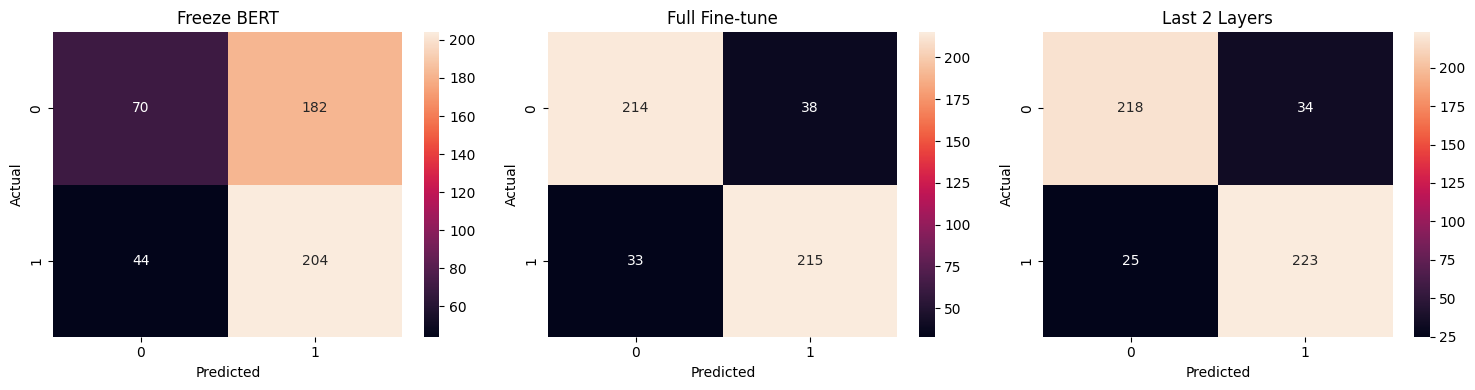

In [57]:
cm_full = confusion_matrix(true_full, preds_full)
cm_freeze = confusion_matrix(true_freeze, preds_freeze)
cm_last2 = confusion_matrix(true_last2, preds_last2)

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Freeze BERT
sns.heatmap(cm_freeze, annot=True, fmt='d', ax=axes[0])
axes[0].set_title("Freeze BERT")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Full Fine-tune
sns.heatmap(cm_full, annot=True, fmt='d', ax=axes[1])
axes[1].set_title("Full Fine-tune")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# Last 2 Layers
sns.heatmap(cm_last2, annot=True, fmt='d', ax=axes[2])
axes[2].set_title("Last 2 Layers")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()

Analysis & Comparison

Three approaches were tested: Freeze BERT, Full Fine-tuning, and Fine-tuning Last 2 Layers.

Freeze BERT performed the worst (Accuracy: 56.6%, F1: 0.63) because the model could not adapt to the dataset. Only the classifier was trained, leading to poor feature learning.

Full Fine-tuning showed strong performance (Accuracy: 85.8%, F1: 0.86) as all layers were updated, allowing the model to learn task-specific patterns. However, it is computationally expensive.

Fine-tuning Last 2 Layers achieved the best results (Accuracy: 87.4%, F1: 0.875). It balances performance and efficiency by keeping lower layers fixed (general knowledge) and adapting higher layers (task-specific learning).